# Spacecraft Docking Controller — Closed-Loop Analysis

Publication-quality analysis of PID closed-loop docking runs in **Isaac Sim + vision pose estimation**.

**Coordinate frames logged in CSV:**
- `pos_*` — relative pose in **camera optical frame** (X=right, Y=down, Z=depth)
- `isaac_pos_*` — same pose remapped to **Isaac command frame** (X=fwd, Y=left, Z=up)
- `gt_pos_*` — Isaac Sim ground truth (if `/spacecraft/ground_truth_pose` is published)
- `err_*` — tracking error (target − current)

Logs: `spacecraft_docking_controller/logs/docking_*.csv`

In [2]:
# Setup — auto-resolves log directory on any machine
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Package root (notebooks/ -> spacecraft_docking_controller/)
PKG_ROOT = Path.cwd().resolve()
if PKG_ROOT.name == 'notebooks':
    PKG_ROOT = PKG_ROOT.parent
if str(PKG_ROOT) not in sys.path:
    sys.path.insert(0, str(PKG_ROOT))

from sdc_core.log_paths import resolve_log_directory, find_latest_log
from sdc_core.plotting import apply_paper_style, generate_all_figures, write_summary

apply_paper_style()

LOG_DIR = Path(resolve_log_directory(caller_file=str(PKG_ROOT / 'sdc_core' / 'log_paths.py')))
LOG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Log directory: {LOG_DIR}')

Log directory: /home/sichentao/Documents/spacecraft_docking_controller/logs


## Quick plot — latest CSV log

Run the cell below after a docking test. Figures save to `LOG_DIR/` (`fig01_*.png`, `docking_paper_figure.png`).

**Or from terminal:**
```bash
cd spacecraft_docking_controller
PYTHONPATH=. python3 scripts/plot_docking_data.py --latest --paper --no-show
```

In [ ]:
# === PLOT LATEST RUN (use this after Isaac Sim test) ===
from sdc_core.log_paths import find_latest_log

latest = find_latest_log(caller_file=str(PKG_ROOT / 'sdc_core' / 'log_paths.py'))
if latest is None:
    raise FileNotFoundError(f'No docking_*.csv in {LOG_DIR}')

print(f'Latest log: {latest}')
df = pd.read_csv(latest)
print(f'{len(df)} points, {df["time"].max():.1f} s')

write_summary(df, str(LOG_DIR))
generate_all_figures(df, str(LOG_DIR), show=True)

from IPython.display import Image, display
display(Image(filename=str(LOG_DIR / 'docking_paper_figure.png')))

## 1. List Available Log Files


In [4]:
# List all available log files (sorted by date, newest first)
log_files = sorted(LOG_DIR.glob('docking_*.csv'), reverse=True)

print("Available log files:")
print("=" * 60)
for i, f in enumerate(log_files):
    size_kb = f.stat().st_size / 1024
    print(f"[{i}] {f.name}  ({size_kb:.1f} KB)")

if not log_files:
    print("No log files found! Run the docking controller first.")
else:
    print(f"\nTotal: {len(log_files)} files")


Available log files:
[0] docking_20260114_115759.csv  (44.3 KB)

Total: 1 files


## 2. Select and Load Log File

Change `FILE_INDEX` to select a different log file (0 = most recent)


In [ ]:
# Generate all publication figures (saved to LOG_DIR)
write_summary(df, str(LOG_DIR))
generate_all_figures(df, str(LOG_DIR), show=True)

# Main figure for thesis slide
from IPython.display import Image, display
display(Image(filename=str(LOG_DIR / 'docking_paper_figure.png')))

In [ ]:
# SELECT FILE: Change this index to load a different file
FILE_INDEX = 0  # 0 = most recent file

# Load the selected file
if log_files:
    selected_file = log_files[FILE_INDEX]
    print(f"Loading: {selected_file.name}")
    
    df = pd.read_csv(selected_file)
    print(f"Loaded {len(df)} data points")
    print(f"Duration: {df['time'].max():.1f} seconds")
    print(f"\nColumns: {list(df.columns)}")
    
    # Show first few rows
    df.head()


Loading: docking_20260114_115759.csv
Loaded 444 data points
Duration: 47.1 seconds

Columns: ['time', 'pos_x', 'pos_y', 'pos_z', 'range', 'range_rate', 'ctrl_x', 'ctrl_y', 'ctrl_z', 'twist_x', 'twist_y', 'twist_z']


## 3. Range vs Time (Main Docking Plot)

This is the key plot showing approach progress.


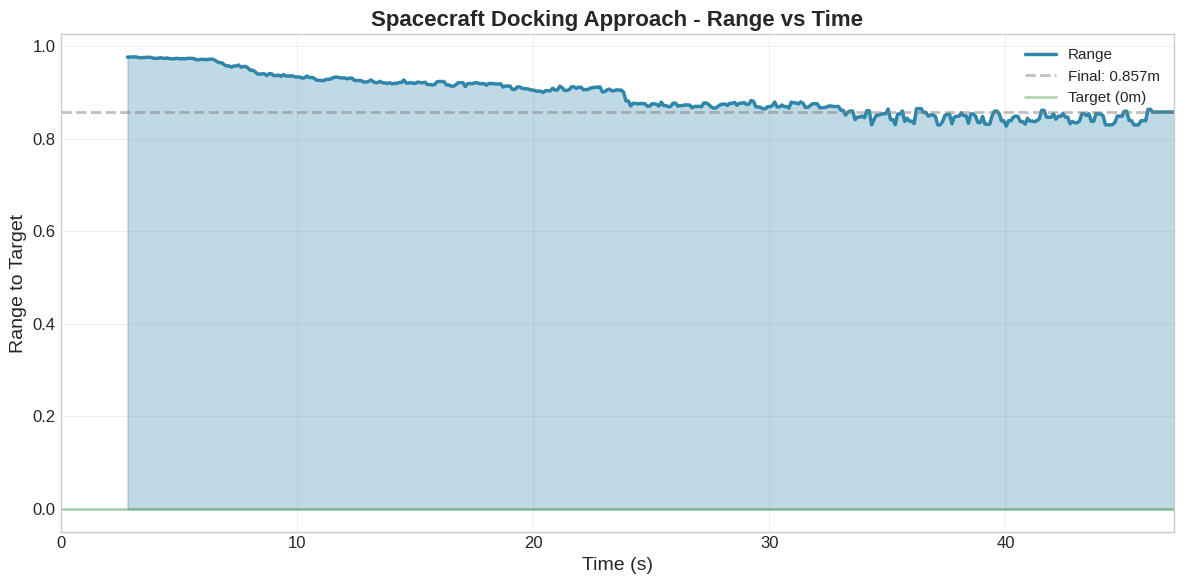

Saved: /home/sichentao/Documents/spacecraft_docking_controller/logs/plot_range_vs_time.png


In [ ]:
# Range vs Time - Main docking approach plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df['time'], df['range'], color='#2E86AB', linewidth=2.5, label='Range')
ax.fill_between(df['time'], df['range'], alpha=0.3, color='#2E86AB')

# Add annotations
initial_range = df['range'].iloc[0]
final_range = df['range'].iloc[-1]
ax.axhline(y=final_range, color='gray', linestyle='--', alpha=0.5, label=f'Final: {final_range:.3f}m')
ax.axhline(y=0, color='green', linestyle='-', alpha=0.3, label='Target (0m)')

ax.set_xlabel('Time (s)')
# ax.set_ylabel('Range to Target (m)')
ax.set_ylabel('Range to Target')
ax.set_title('Spacecraft Docking Approach - Range vs Time', fontweight='bold', fontsize=16)
ax.legend(loc='upper right')
ax.set_xlim(0, df['time'].max())

# Stats annotation
# reduction = (1 - final_range/initial_range) * 100
# ax.text(0.02, 0.98, f'Initial: {initial_range:.3f}m\nFinal: {final_range:.3f}m\nReduction: {reduction:.1f}%',
#         transform=ax.transAxes, fontsize=11, verticalalignment='top',
#         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(LOG_DIR / 'plot_range_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {LOG_DIR / 'plot_range_vs_time.png'}")


## 4. Range Rate (Approach Velocity)


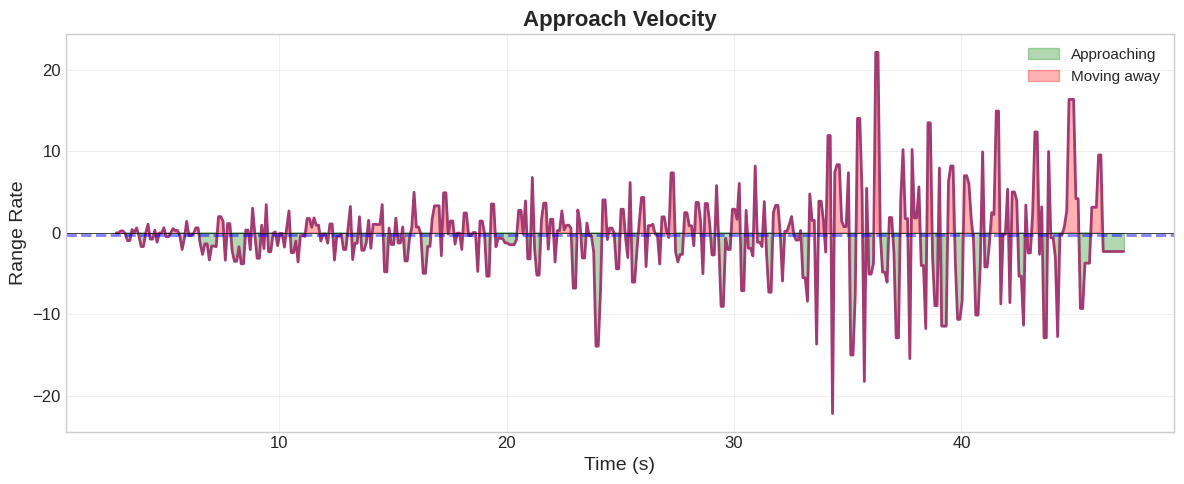

In [ ]:
# Range Rate (Approach Velocity)
fig, ax = plt.subplots(figsize=(12, 5))

# Convert to cm/s for better readability
rate_cms = df['range_rate'] * 100

ax.plot(df['time'], rate_cms, color='#A23B72', linewidth=2)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Color positive (moving away) vs negative (approaching)
ax.fill_between(df['time'], rate_cms, 0, where=(rate_cms < 0), 
                color='green', alpha=0.3, label='Approaching')
ax.fill_between(df['time'], rate_cms, 0, where=(rate_cms > 0), 
                color='red', alpha=0.3, label='Moving away')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Range Rate')
# ax.set_ylabel('Range Rate (cm/s)')
ax.set_title('Approach Velocity', fontweight='bold')
ax.legend(loc='upper right')

avg_rate = rate_cms.mean()
ax.axhline(y=avg_rate, color='blue', linestyle='--', alpha=0.5, label=f'Avg: {avg_rate:.2f} cm/s')

plt.tight_layout()
plt.savefig(LOG_DIR / 'plot_range_rate.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Position Components (X, Y, Z)


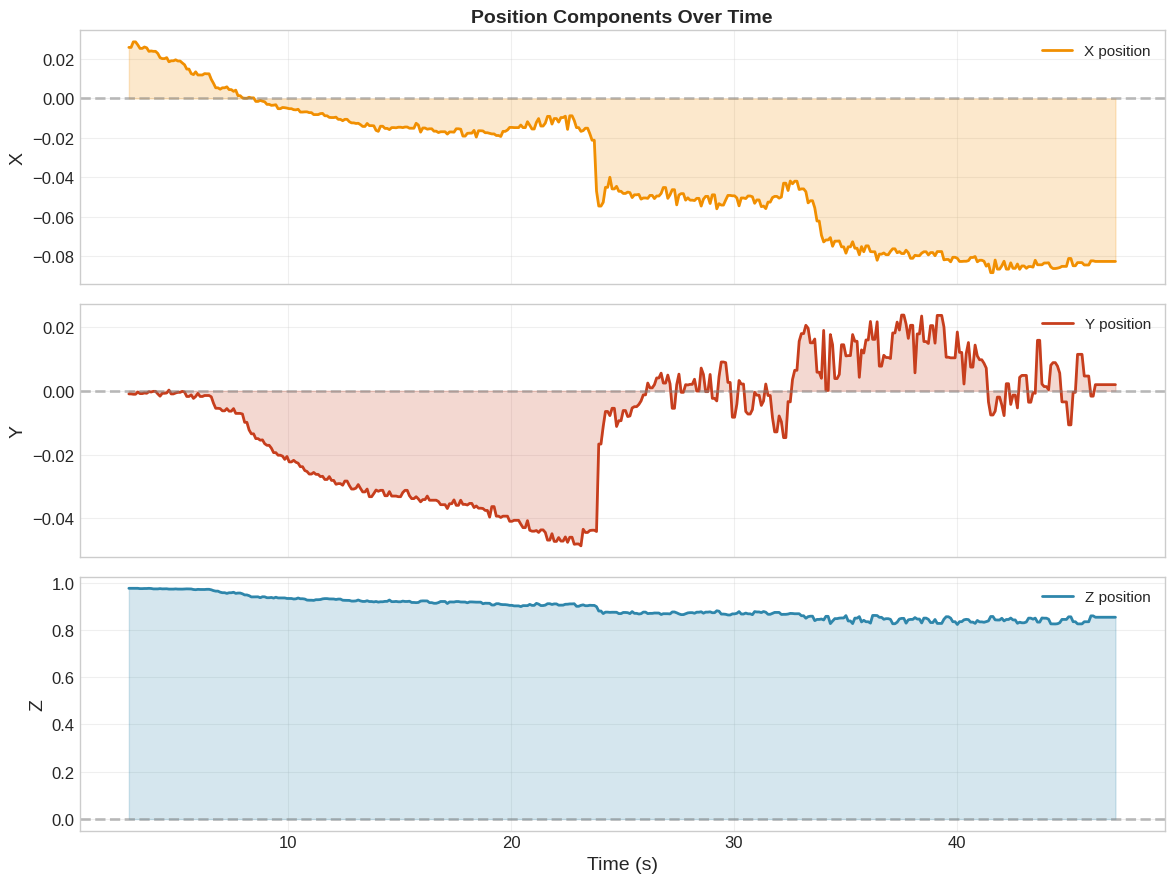

In [ ]:
# Position Components
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

colors = {'x': '#F18F01', 'y': '#C73E1D', 'z': '#2E86AB'}

for ax, (axis, color) in zip(axes, colors.items()):
    col = f'pos_{axis}'
    ax.plot(df['time'], df[col], color=color, linewidth=2, label=f'{axis.upper()} position')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    # ax.set_ylabel(f'{axis.upper()} (m)')
    ax.set_ylabel(f'{axis.upper()}')
    ax.legend(loc='upper right')
    ax.fill_between(df['time'], df[col], 0, alpha=0.2, color=color)

axes[-1].set_xlabel('Time (s)')
axes[0].set_title('Position Components Over Time', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig(LOG_DIR / 'plot_position_components.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. 2D Trajectory Plots


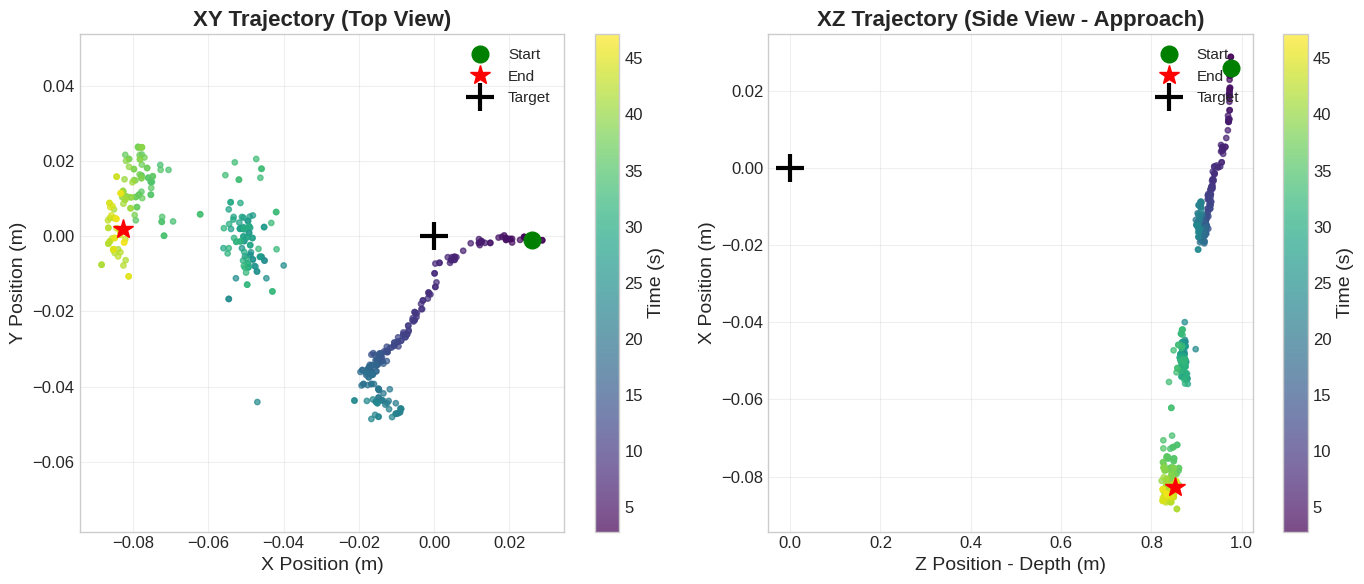

In [ ]:
# 2D Trajectory Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XY Trajectory (Top View)
ax1 = axes[0]
scatter1 = ax1.scatter(df['pos_x'], df['pos_y'], c=df['time'], cmap='viridis', s=15, alpha=0.7)
ax1.plot(df['pos_x'].iloc[0], df['pos_y'].iloc[0], 'go', markersize=12, label='Start', zorder=5)
ax1.plot(df['pos_x'].iloc[-1], df['pos_y'].iloc[-1], 'r*', markersize=15, label='End', zorder=5)
ax1.plot(0, 0, 'k+', markersize=20, markeredgewidth=3, label='Target', zorder=5)
ax1.set_xlabel('X Position (m)')
ax1.set_ylabel('Y Position (m)')
ax1.set_title('XY Trajectory (Top View)', fontweight='bold')
ax1.legend(loc='upper right')
ax1.axis('equal')
plt.colorbar(scatter1, ax=ax1, label='Time (s)')

# XZ Trajectory (Side View - Approach)
ax2 = axes[1]
scatter2 = ax2.scatter(df['pos_z'], df['pos_x'], c=df['time'], cmap='viridis', s=15, alpha=0.7)
ax2.plot(df['pos_z'].iloc[0], df['pos_x'].iloc[0], 'go', markersize=12, label='Start', zorder=5)
ax2.plot(df['pos_z'].iloc[-1], df['pos_x'].iloc[-1], 'r*', markersize=15, label='End', zorder=5)
ax2.plot(0, 0, 'k+', markersize=20, markeredgewidth=3, label='Target', zorder=5)
ax2.set_xlabel('Z Position - Depth (m)')
ax2.set_ylabel('X Position (m)')
ax2.set_title('XZ Trajectory (Side View - Approach)', fontweight='bold')
ax2.legend(loc='upper right')
plt.colorbar(scatter2, ax=ax2, label='Time (s)')

plt.tight_layout()
plt.savefig(LOG_DIR / 'plot_trajectory_2d.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Control Outputs and Velocity Commands


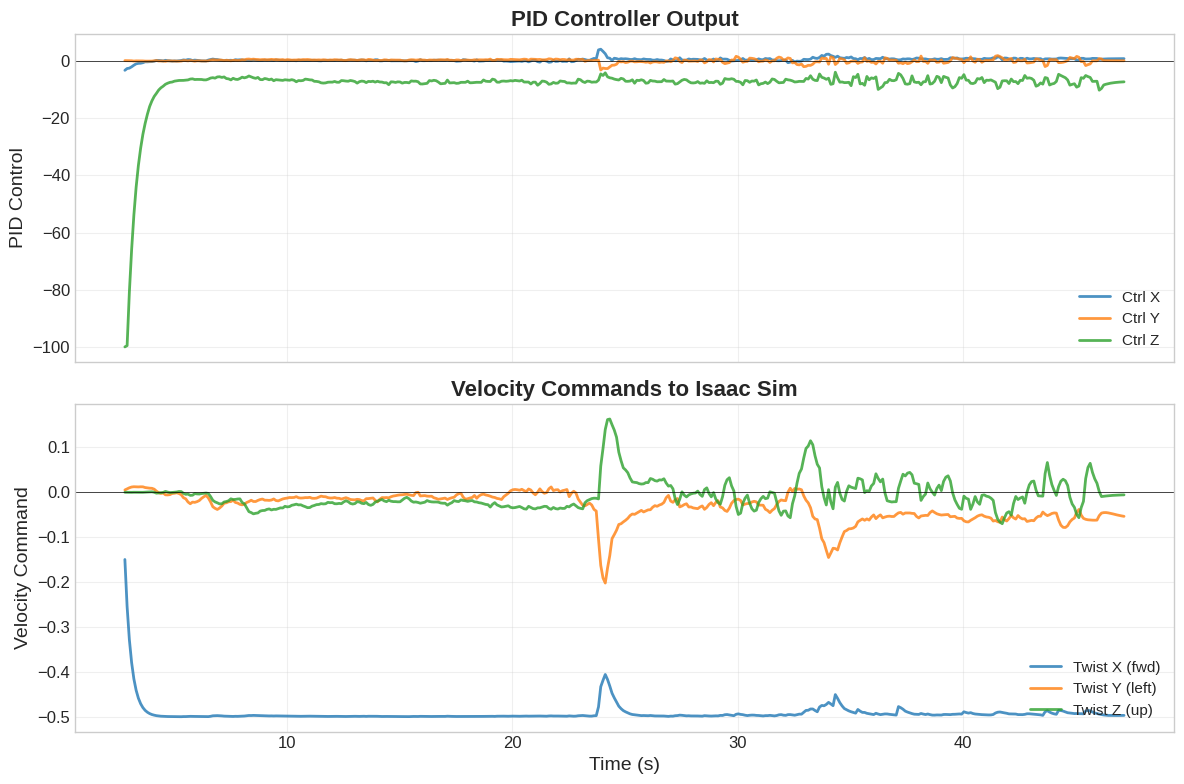

In [ ]:
# Control Outputs and Twist Commands
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Control outputs (PID)
ax1 = axes[0]
ax1.plot(df['time'], df['ctrl_x'] * 1000, label='Ctrl X', alpha=0.8)
ax1.plot(df['time'], df['ctrl_y'] * 1000, label='Ctrl Y', alpha=0.8)
ax1.plot(df['time'], df['ctrl_z'] * 1000, label='Ctrl Z', alpha=0.8)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
# ax1.set_ylabel('PID Control (mm/s²)')
ax1.set_ylabel('PID Control')
ax1.set_title('PID Controller Output', fontweight='bold')
ax1.legend(loc='lower right')

# Twist commands (velocity sent to Isaac Sim)
ax2 = axes[1]
ax2.plot(df['time'], df['twist_x'] * 100, label='Twist X (fwd)', alpha=0.8)
ax2.plot(df['time'], df['twist_y'] * 100, label='Twist Y (left)', alpha=0.8)
ax2.plot(df['time'], df['twist_z'] * 100, label='Twist Z (up)', alpha=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Time (s)')
# ax2.set_ylabel('Velocity Command (cm/s)')
ax2.set_ylabel('Velocity Command')
ax2.set_title('Velocity Commands to Isaac Sim', fontweight='bold')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig(LOG_DIR / 'plot_control_outputs.png', dpi=150, bbox_inches='tight')
plt.show()


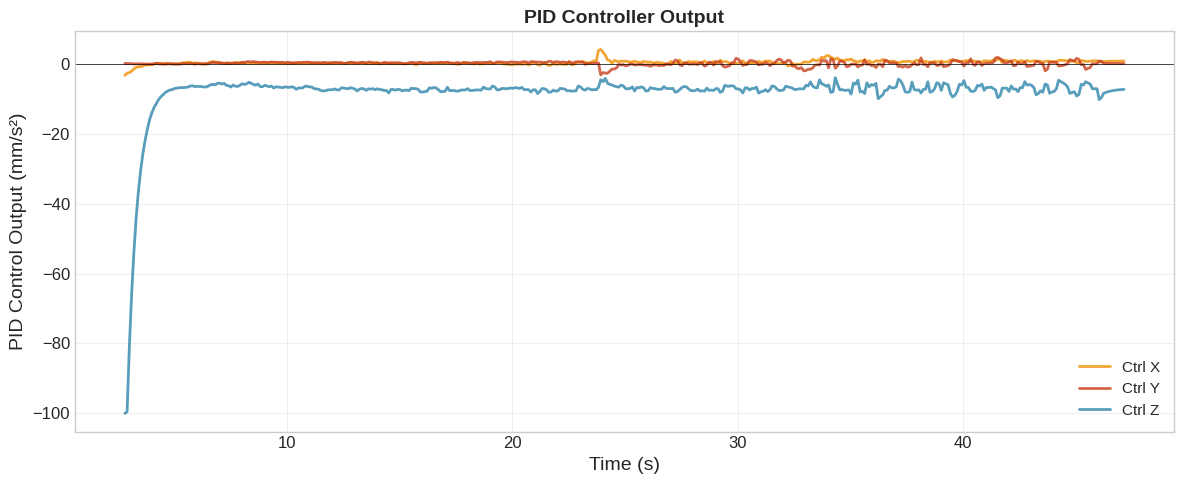

In [ ]:
# PID Control Outputs
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['time'], df['ctrl_x'] * 1000, label='Ctrl X', alpha=0.8, color='#F18F01')
ax.plot(df['time'], df['ctrl_y'] * 1000, label='Ctrl Y', alpha=0.8, color='#C73E1D')
ax.plot(df['time'], df['ctrl_z'] * 1000, label='Ctrl Z', alpha=0.8, color='#2E86AB')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('PID Control Output (mm/s²)')
ax.set_title('PID Controller Output', fontweight='bold', fontsize=14)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(LOG_DIR / 'plot_pid_control.png', dpi=150, bbox_inches='tight')
plt.show()


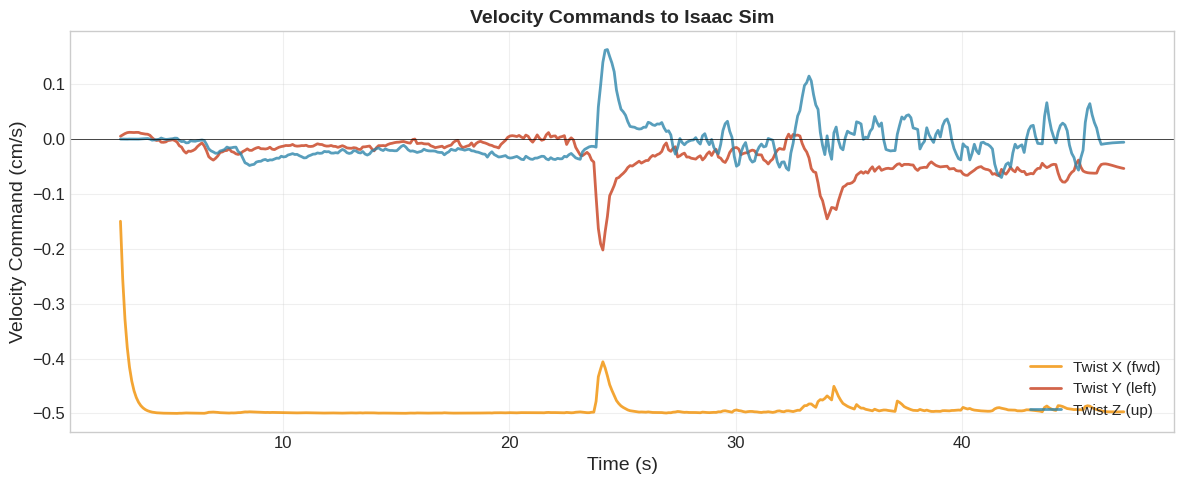

In [ ]:
# Twist Commands (Velocity sent to Isaac Sim)
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['time'], df['twist_x'] * 100, label='Twist X (fwd)', alpha=0.8, color='#F18F01')
ax.plot(df['time'], df['twist_y'] * 100, label='Twist Y (left)', alpha=0.8, color='#C73E1D')
ax.plot(df['time'], df['twist_z'] * 100, label='Twist Z (up)', alpha=0.8, color='#2E86AB')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Velocity Command (cm/s)')
ax.set_title('Velocity Commands to Isaac Sim', fontweight='bold', fontsize=14)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(LOG_DIR / 'plot_twist_commands.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Summary Statistics


In [ ]:
# Summary Statistics
print("=" * 60)
print("DOCKING PERFORMANCE SUMMARY")
print("=" * 60)

initial_range = df['range'].iloc[0]
final_range = df['range'].iloc[-1]
min_range = df['range'].min()
total_time = df['time'].iloc[-1]

print(f"\n📍 RANGE:")
print(f"   Initial:     {initial_range:.4f} m")
print(f"   Final:       {final_range:.4f} m")
print(f"   Minimum:     {min_range:.4f} m")
print(f"   Reduction:   {(1 - final_range/initial_range) * 100:.1f}%")

print(f"\n⏱️ TIME:")
print(f"   Duration:    {total_time:.1f} s")
print(f"   Data points: {len(df)}")

avg_rate = (initial_range - final_range) / total_time
print(f"\n🚀 VELOCITY:")
print(f"   Avg approach rate: {avg_rate * 100:.3f} cm/s")
print(f"   Max |rate|:        {df['range_rate'].abs().max() * 100:.3f} cm/s")

print(f"\n🎛️ CONTROL:")
print(f"   Max |ctrl_x|: {df['ctrl_x'].abs().max() * 1000:.3f} mm/s²")
print(f"   Max |ctrl_y|: {df['ctrl_y'].abs().max() * 1000:.3f} mm/s²")
print(f"   Max |ctrl_z|: {df['ctrl_z'].abs().max() * 1000:.3f} mm/s²")

print(f"\n📊 POSITION (final):")
print(f"   X: {df['pos_x'].iloc[-1]:.4f} m")
print(f"   Y: {df['pos_y'].iloc[-1]:.4f} m")
print(f"   Z: {df['pos_z'].iloc[-1]:.4f} m")

print("\n" + "=" * 60)


## 9. 3D Trajectory Visualization


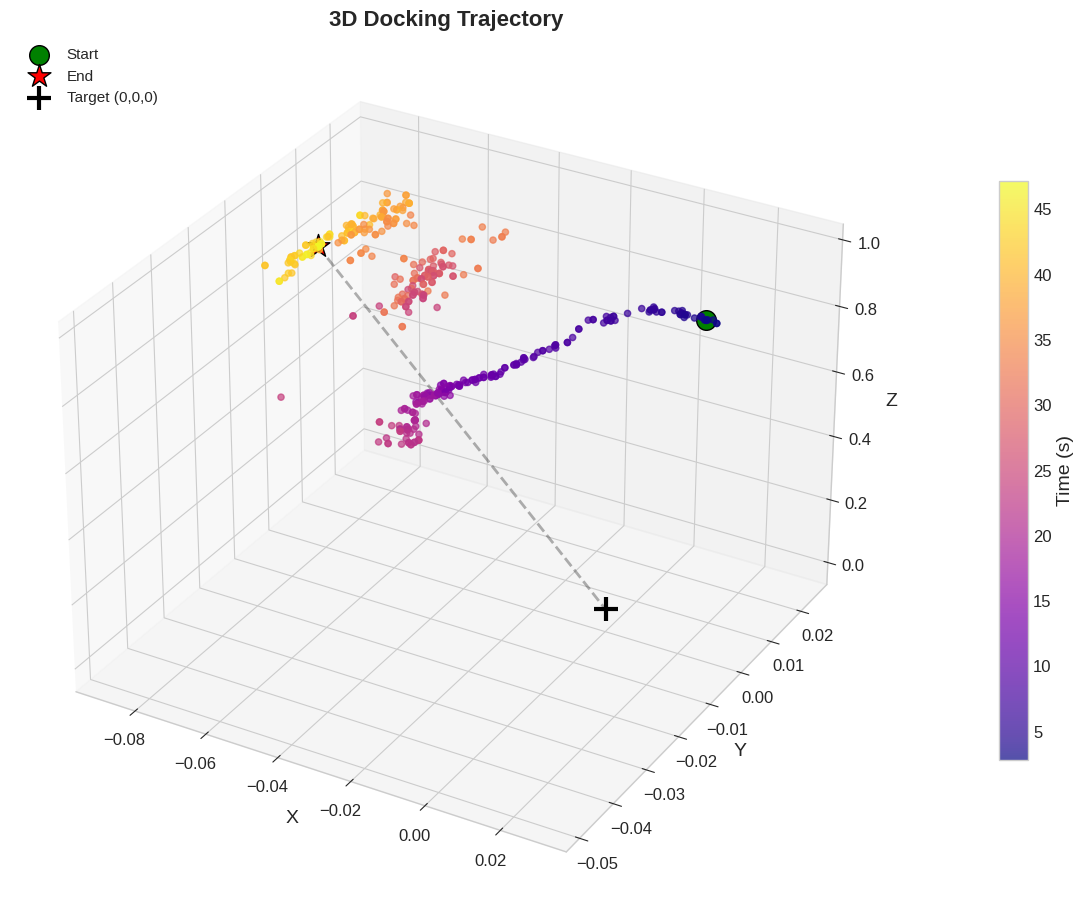

In [ ]:
# 3D Trajectory Plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot trajectory colored by time
scatter = ax.scatter(df['pos_x'], df['pos_y'], df['pos_z'], 
                     c=df['time'], cmap='plasma', s=20, alpha=0.7)

# Highlight start and end
ax.scatter(df['pos_x'].iloc[0], df['pos_y'].iloc[0], df['pos_z'].iloc[0],
           c='green', s=200, marker='o', label='Start', edgecolor='black')
ax.scatter(df['pos_x'].iloc[-1], df['pos_y'].iloc[-1], df['pos_z'].iloc[-1],
           c='red', s=300, marker='*', label='End', edgecolor='black')

# Target at origin
ax.scatter(0, 0, 0, c='black', s=300, marker='+', linewidths=3, label='Target (0,0,0)')

# Draw line from last position to target
ax.plot([df['pos_x'].iloc[-1], 0], [df['pos_y'].iloc[-1], 0], [df['pos_z'].iloc[-1], 0],
        'k--', alpha=0.3, linewidth=2)

# ax.set_xlabel('X (m)')
# ax.set_ylabel('Y (m)')
# ax.set_zlabel('Z (m)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Docking Trajectory', fontweight='bold', fontsize=16)
ax.legend(loc='upper left')

plt.colorbar(scatter, label='Time (s)', shrink=0.6, pad=0.1)
plt.tight_layout()
plt.savefig(LOG_DIR / 'plot_trajectory_3d.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Control-Theory Analysis (Reference, Error, Command, Response)

Classic closed-loop view for thesis / control documentation:

| Signal | In this log | Meaning |
|--------|-------------|---------|
| **Reference** \(r\) | \(0\) (docking port at origin) | Desired relative pose |
| **Output** \(y\) | `pos_x`, `pos_y`, `pos_z` | Vision pose (measurement) |
| **Error** \(e = y - r\) | `pos_*`, `range` | Tracking error (controller convention) |
| **Control** \(u\) | `ctrl_*` | PID/LQR acceleration command |
| **Actuator** | `twist_*` | Velocity sent to Isaac Sim |
| **Response rate** | `range_rate`, \(\dot{y}\) from pose | Closing / measured speed |

Plots saved as `plot_control_theory_*.png` in `LOG_DIR`.

In [ ]:
# --- Derived signals (target at origin, same as docking_controller_node) ---
t = df['time'].values
# Reference r = 0.  Controller uses e = y - r  =>  e_x = pos_x,  ||e|| = range
err_x = df['pos_x'].values
err_y = df['pos_y'].values
err_z = df['pos_z'].values
e_norm = df['range'].values

# Numerical velocity from pose (vision "response" rate); matches controller finite-diff idea
dt = np.diff(t, prepend=t[0])
dt[dt < 1e-6] = np.nan
vel_x = np.gradient(df['pos_x'].values, t)
vel_y = np.gradient(df['pos_y'].values, t)
vel_z = np.gradient(df['pos_z'].values, t)

u_x = df['ctrl_x'].values
u_y = df['ctrl_y'].values
u_z = df['ctrl_z'].values
cmd_x = df['twist_x'].values
cmd_y = df['twist_y'].values
cmd_z = df['twist_z'].values

axis_colors = {'x': '#F18F01', 'y': '#C73E1D', 'z': '#2E86AB'}

# 1) Reference vs measured output (per axis)
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, axis, err, pos, color in zip(
    axes,
    ['x', 'y', 'z'],
    [err_x, err_y, err_z],
    [df['pos_x'], df['pos_y'], df['pos_z']],
    axis_colors.values(),
):
    ax.axhline(0, color='green', linestyle='--', linewidth=1.5, label='Reference r=0')
    ax.plot(t, pos, color=color, linewidth=2, label=f'Measured y_{axis} (pose)')
    ax.plot(t, err, color='gray', linestyle=':', linewidth=1.5, alpha=0.8, label=f'e_{axis} = y_{axis} − r')
    ax.set_ylabel(f'{axis.upper()} (m)')
    ax.legend(loc='upper right', fontsize=9)
axes[-1].set_xlabel('Time (s)')
axes[0].set_title('Tracking: Reference vs Pose Measurement', fontweight='bold', fontsize=14)
fig.tight_layout()
plt.savefig(LOG_DIR / 'plot_control_theory_tracking.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {LOG_DIR / "plot_control_theory_tracking.png"}')

# 2) Error dynamics e(t) and ||e||
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax0, ax1 = axes
for axis, err, color in zip(['x', 'y', 'z'], [err_x, err_y, err_z], axis_colors.values()):
    ax0.plot(t, err, color=color, linewidth=1.8, label=f'e_{axis}')
ax0.axhline(0, color='black', linewidth=0.5)
ax0.set_ylabel('Error e (m)')
ax0.set_title('Tracking Error e(t)  (y − r,  r = 0)', fontweight='bold')
ax0.legend(loc='upper right')

ax1.plot(t, e_norm, color='#2E86AB', linewidth=2.5, label='||e|| = range')
ax1.fill_between(t, e_norm, alpha=0.25, color='#2E86AB')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('||e|| (m)')
ax1.legend(loc='upper right')
fig.tight_layout()
plt.savefig(LOG_DIR / 'plot_control_theory_error.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {LOG_DIR / "plot_control_theory_error.png"}')

# 3) Control effort u(t) vs error e(t)  (shows controller gain / saturation behaviour)
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, axis, err, u, color in zip(
    axes,
    ['x', 'y', 'z'],
    [err_x, err_y, err_z],
    [u_x, u_y, u_z],
    axis_colors.values(),
):
    ax2 = ax.twinx()
    l1, = ax.plot(t, err, color=color, linewidth=2, label=f'e_{axis} (m)')
    l2, = ax2.plot(t, u * 1000, color='black', linewidth=1.5, alpha=0.7, label=f'u_{axis} (mm/s²)')
    ax.set_ylabel(f'e_{axis} (m)', color=color)
    ax2.set_ylabel(f'u_{axis} (mm/s²)', color='black')
    ax.legend(handles=[l1, l2], loc='upper right', fontsize=9)
axes[-1].set_xlabel('Time (s)')
axes[0].set_title('Control Law: Error vs Acceleration Command u(t)', fontweight='bold', fontsize=14)
fig.tight_layout()
plt.savefig(LOG_DIR / 'plot_control_theory_command_vs_error.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {LOG_DIR / "plot_control_theory_command_vs_error.png"}')

# 4) Actuation: velocity command vs measured pose rate (response)
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, axis, v_meas, v_cmd, color in zip(
    axes,
    ['x', 'y', 'z'],
    [vel_x, vel_y, vel_z],
    [cmd_x, cmd_y, cmd_z],
    axis_colors.values(),
):
    ax.plot(t, v_meas * 100, color=color, linewidth=2, label=f'dy_{axis}/dt from pose (cm/s)')
    ax.plot(t, v_cmd * 100, color='black', linestyle='--', linewidth=1.5, alpha=0.8,
            label=f'twist_{axis} cmd (cm/s)')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_ylabel('Velocity (cm/s)')
    ax.legend(loc='upper right', fontsize=9)
axes[-1].set_xlabel('Time (s)')
axes[0].set_title('Actuation vs Response: Twist Command vs Pose-Differentiated Velocity',
                   fontweight='bold', fontsize=14)
fig.tight_layout()
plt.savefig(LOG_DIR / 'plot_control_theory_actuation_vs_response.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {LOG_DIR / "plot_control_theory_actuation_vs_response.png"}')

# 5) Phase plane: range vs range rate (approach stability)
fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(e_norm, df['range_rate'] * 100, c=t, cmap='viridis', s=12, alpha=0.75)
ax.plot(e_norm.iloc[0], df['range_rate'].iloc[0] * 100, 'go', markersize=12, label='Start', zorder=5)
ax.plot(e_norm.iloc[-1], df['range_rate'].iloc[-1] * 100, 'r*', markersize=14, label='End', zorder=5)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='green', linestyle='--', alpha=0.4, label='Target ||e||=0')
ax.set_xlabel('||e|| — range to target (m)')
ax.set_ylabel('range_rate (cm/s)')
ax.set_title('Phase Plane: Range vs Closing Rate', fontweight='bold')
ax.legend(loc='upper right')
plt.colorbar(sc, label='Time (s)')
fig.tight_layout()
plt.savefig(LOG_DIR / 'plot_control_theory_phase_plane.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {LOG_DIR / "plot_control_theory_phase_plane.png"}')

# 6) Single "textbook" block diagram time series (stacked)
fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)
axes[0].plot(t, e_norm, color='#2E86AB', linewidth=2)
axes[0].set_ylabel('||e|| (m)')
axes[0].set_title('Closed-loop signals (vision-based docking)', fontweight='bold', fontsize=14)

axes[1].plot(t, df['range_rate'] * 100, color='#A23B72', linewidth=2)
axes[1].set_ylabel('range_rate\n(cm/s)')

axes[2].plot(t, u_x, label='ux', alpha=0.8)
axes[2].plot(t, u_y, label='uy', alpha=0.8)
axes[2].plot(t, u_z, label='uz', alpha=0.8)
axes[2].set_ylabel('u = ctrl\n(m/s²)')
axes[2].legend(loc='upper right', ncol=3, fontsize=9)

axes[3].plot(t, cmd_x * 100, label='twist_x', alpha=0.8)
axes[3].plot(t, cmd_y * 100, label='twist_y', alpha=0.8)
axes[3].plot(t, cmd_z * 100, label='twist_z', alpha=0.8)
axes[3].set_ylabel('actuator\n(cm/s)')
axes[3].legend(loc='upper right', ncol=3, fontsize=9)

axes[4].plot(t, df['pos_z'], color=axis_colors['z'], linewidth=2, label='depth z')
axes[4].set_ylabel('pose z (m)')
axes[4].set_xlabel('Time (s)')
axes[4].legend(loc='upper right')

for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(LOG_DIR / 'plot_control_theory_block_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {LOG_DIR / "plot_control_theory_block_diagram.png"}')

## 8b. Raw vision pose (isaac_multitask) vs controller commands

Requires a **new** CSV log with columns `raw_pos_x,raw_pos_y,raw_pos_z` (controller ≥ latest build with `log_vision_raw_pose: true`).

| Column | Source |
|--------|--------|
| `raw_pos_*` | `/vision_benchmark/pose_xyz_quat` from **isaac_multitask_node** |
| `pos_*` | `/pose_estimation/object_pose` after **bridge** (what PID uses) |
| `ctrl_*` | PID acceleration command (camera frame) |
| `twist_*` | Velocity command to Isaac (after remap) |

In [ ]:
# Raw isaac_multitask pose vs controller commands
required = {'raw_pos_x', 'raw_pos_y', 'raw_pos_z'}
if not required.issubset(df.columns):
    print('This log has no raw_pos_* columns (old CSV).')
    print('Rebuild controller, enable logging, run a new docking test, then re-load.')
else:
    t = df['time']
    axis_colors = {'x': '#F18F01', 'y': '#C73E1D', 'z': '#2E86AB'}

    # 1) Raw vision position vs bridged position (per axis)
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    for ax, axis, color in zip(axes, ['x', 'y', 'z'], axis_colors.values()):
        ax.plot(t, df[f'raw_pos_{axis}'], '--', color=color, linewidth=1.5,
                label=f'raw_pos_{axis} (isaac_multitask)', alpha=0.9)
        ax.plot(t, df[f'pos_{axis}'], '-', color=color, linewidth=2,
                label=f'pos_{axis} (bridge -> controller)')
        ax.set_ylabel(f'{axis.upper()} (m)')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel('Time (s)')
    axes[0].set_title('Vision raw pose vs pose used by controller', fontweight='bold', fontsize=14)
    fig.tight_layout()
    plt.savefig(LOG_DIR / 'plot_raw_vs_bridge_pose.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {LOG_DIR / "plot_raw_vs_bridge_pose.png"}')

    # 2) Raw pose + PID command (dual axis per axis)
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    for ax, axis, color in zip(axes, ['x', 'y', 'z'], axis_colors.values()):
        ax2 = ax.twinx()
        l1, = ax.plot(t, df[f'raw_pos_{axis}'], color=color, linewidth=2,
                      label=f'raw_pos_{axis} (m)')
        l2, = ax2.plot(t, df[f'ctrl_{axis}'] * 1000, color='black', linewidth=1.5, alpha=0.75,
                       label=f'ctrl_{axis} (mm/s²)')
        ax.set_ylabel('raw pose (m)', color=color)
        ax2.set_ylabel('ctrl (mm/s²)', color='black')
        ax.legend(handles=[l1, l2], loc='upper right', fontsize=9)
    axes[-1].set_xlabel('Time (s)')
    axes[0].set_title('Raw vision pose vs PID control command u(t)', fontweight='bold', fontsize=14)
    fig.tight_layout()
    plt.savefig(LOG_DIR / 'plot_raw_pose_vs_command.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {LOG_DIR / "plot_raw_pose_vs_command.png"}')

    # 3) Raw pose + twist command (actuator)
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    for ax, axis, color in zip(axes, ['x', 'y', 'z'], axis_colors.values()):
        ax2 = ax.twinx()
        l1, = ax.plot(t, df[f'raw_pos_{axis}'], color=color, linewidth=2,
                      label=f'raw_pos_{axis} (m)')
        l2, = ax2.plot(t, df[f'twist_{axis}'] * 100, color='black', linewidth=1.5, alpha=0.75,
                       label=f'twist_{axis} (cm/s)')
        ax.set_ylabel('raw pose (m)', color=color)
        ax2.set_ylabel('twist (cm/s)', color='black')
        ax.legend(handles=[l1, l2], loc='upper right', fontsize=9)
    axes[-1].set_xlabel('Time (s)')
    axes[0].set_title('Raw vision pose vs twist command to Isaac Sim', fontweight='bold', fontsize=14)
    fig.tight_layout()
    plt.savefig(LOG_DIR / 'plot_raw_pose_vs_twist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {LOG_DIR / "plot_raw_pose_vs_twist.png"}')

    # 4) Overlay summary: depth (raw z) vs range vs |ctrl|
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    axes[0].plot(t, df['raw_pos_z'], color=axis_colors['z'], linewidth=2, label='raw_pos_z')
    axes[0].plot(t, df['pos_z'], '--', color=axis_colors['z'], linewidth=1.5, label='pos_z (bridge)')
    axes[0].set_ylabel('Z (m)')
    axes[0].legend(loc='upper right')
    axes[0].set_title('Depth + tracking + control magnitude', fontweight='bold')

    axes[1].plot(t, df['range'], color='#2E86AB', linewidth=2)
    axes[1].set_ylabel('range (m)')

    ctrl_mag = np.sqrt(df['ctrl_x']**2 + df['ctrl_y']**2 + df['ctrl_z']**2) * 1000
    axes[2].plot(t, ctrl_mag, color='#44803F', linewidth=2)
    axes[2].set_ylabel('|u| (mm/s²)')
    axes[2].set_xlabel('Time (s)')
    fig.tight_layout()
    plt.savefig(LOG_DIR / 'plot_raw_pose_command_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {LOG_DIR / "plot_raw_pose_command_summary.png"}')

## 10. Compare Multiple Runs

Load and compare different docking attempts


In [ ]:
# Compare Multiple Runs - Select indices of files to compare
# Change these to compare different runs
FILES_TO_COMPARE = [0, 1, 2]  # Index from the log_files list (0 = newest)

# Load selected files
runs = {}
for idx in FILES_TO_COMPARE:
    if idx < len(log_files):
        f = log_files[idx]
        try:
            data = pd.read_csv(f)
            if len(data) > 0:
                runs[f.name] = data
                print(f"✓ Loaded: {f.name} ({len(data)} points)")
        except:
            print(f"✗ Failed: {f.name}")
    else:
        print(f"✗ Index {idx} out of range")

if len(runs) < 2:
    print("\nNeed at least 2 valid runs to compare!")


In [ ]:
# Compare Range vs Time for multiple runs
if len(runs) >= 2:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = plt.cm.tab10.colors
    for i, (name, data) in enumerate(runs.items()):
        # Extract date/time from filename for legend
        short_name = name.replace('docking_', '').replace('.csv', '')
        ax.plot(data['time'], data['range'], 
                color=colors[i % len(colors)], linewidth=2,
                label=f'{short_name}', alpha=0.8)
    
    ax.axhline(y=0, color='green', linestyle='--', alpha=0.3, label='Target')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Range (m)')
    ax.set_title('Range Comparison Across Runs', fontweight='bold', fontsize=16)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig(LOG_DIR / 'plot_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Not enough runs to compare")


## 11. Utilities

Cleanup old logs (optional)


In [ ]:
# Utility: Delete old log files (keep N most recent)
# ⚠️ UNCOMMENT AND RUN ONLY IF YOU WANT TO DELETE OLD LOGS!

# KEEP_N_RECENT = 10  # Number of recent files to keep
# 
# log_files = sorted(LOG_DIR.glob('docking_*.csv'), reverse=True)
# files_to_delete = log_files[KEEP_N_RECENT:]
# 
# if files_to_delete:
#     print(f"Will delete {len(files_to_delete)} old log files...")
#     for f in files_to_delete:
#         print(f"  Deleting: {f.name}")
#         # f.unlink()  # Uncomment to actually delete
#     print("Done! (Uncomment f.unlink() to actually delete)")
# else:
#     print(f"Nothing to delete. Only {len(log_files)} files exist.")
